Author: Lijing Wang (lijing.wang@uconn.edu, https://lijingwang.github.io/) for ERTH 4735 at University of Connecticut

In [1]:
from google.colab import drive
drive.mount('/content/drive') # check that: See, edit, create, and delete all of your Google Drive files

!chmod 755 /content/drive/MyDrive/mf6 # make sure we have the access to mf6

Mounted at /content/drive


In [2]:
! pip install flopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.4 MB/s eta 0:00:00


In [3]:
import flopy
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from flopy.plot import PlotMapView
from flopy.plot import PlotCrossSection
from flopy.discretization import StructuredGrid, VertexGrid
from flopy.utils.lgrutil import Lgr
from flopy.utils.gridgen import Gridgen
from flopy.utils.triangle import Triangle
from flopy.utils.voronoi import VoronoiGrid
from flopy.utils.rasters import Raster
from flopy.utils.gridintersect import GridIntersect

import warnings
warnings.simplefilter("ignore", DeprecationWarning)

## Creating a structured grid


In [4]:
xmin = 0
xmax = 200
ymin = 0
ymax = 100
dx = dy = 2 # Horizontal resolution, here is 20m, but you can make it larger
lx = xmax - xmin
ly = ymax - ymin
nlay = 3 # 3 layers of model
nrow = int(np.floor(ly / dy))
ncol = int(np.floor(lx / dx))
delc = np.full((nrow,), dx)
delr = np.full((ncol,), dy)


top = np.zeros((nrow, ncol)) # Start with a top layer at surface (0 m), and it is a flat area.
botm = np.zeros((nlay, nrow, ncol))
idomain = np.ones((nlay, nrow, ncol), dtype=int)

botm[0,:,:] = top - 1 # first layer, soil, 1m
botm[1,:,:] = botm[0,:,:] - 3 # second layer, saprolite 1, 3m
botm[2,:,:] = botm[1,:,:] - 10 # third layer, saprolite 2, 10m. Therefore the depth to the bedrock is 1m + 3m + 10m = 14m.

sgrid = StructuredGrid(
    delc=delc,
    delr=delr,
    top=top,
    botm=botm,
    idomain=idomain,
    xoff=xmin,
    yoff=ymin
)

# Observations: groundwater tables within three wells

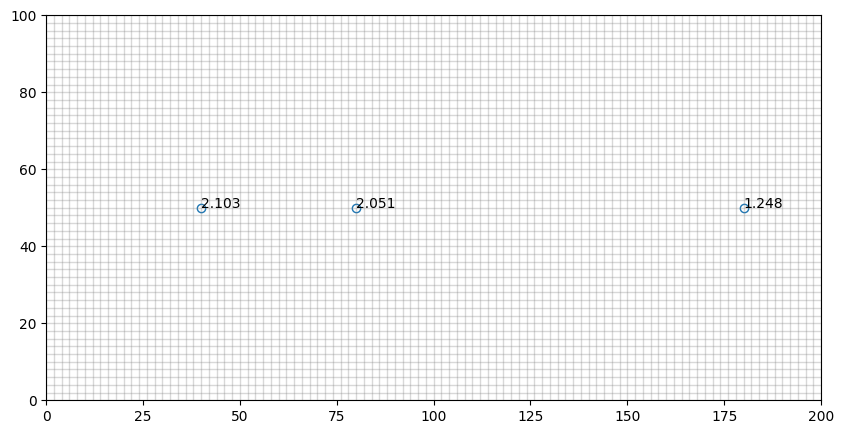

In [5]:
# 2.103,2.051,1.248
observed_gw_tables = np.array([2.103,2.051,1.248])
fig, ax = plt.subplots(figsize=(10, 5))
pmv = PlotMapView(modelgrid=sgrid, ax=ax)
pmv.plot_grid(lw=1,alpha = 0.3)
well_idx = 0
for i,j in [[20,25],[40,25],[90,25]]:
  plt.scatter(i*dx,j*dx,edgecolor = 'C0',color = 'white')
  plt.text(i*dx,j*dx,observed_gw_tables[well_idx])
  well_idx = well_idx+1

# Build a hydrologic model

In [9]:
# ! rm -r ERTH4735_Lab4
ws = Path("ERTH4735_Lab4") # working folder path
name = "Lab4" # simulation name

In [10]:
# create simulation (sim = flopy.mf6.MFSimulation())

# Set the path to the MODFLOW 6 executable compiled with mfpymake
mf6_exe_path = '/content/drive/MyDrive/mf6'  # Adjust the path if the executable is in another directory

# Create a MODFLOW 6 simulation
sim = flopy.mf6.MFSimulation(sim_name=name, exe_name=mf6_exe_path, version='mf6', sim_ws=ws)

# create dis package (tdis = flopy.mf6.ModflowTdis(sim))
tdis = flopy.mf6.ModflowTdis(sim)

# create iterative model solution (ims = flopy.mf6.ModflowIms(sim))
ims = flopy.mf6.ModflowIms(sim)

# Create the groundwater flow model object (`gwf`) using `flopy.mf6.ModflowGwf()`.
gwf = flopy.mf6.ModflowGwf(sim, modelname=name)

# dis data
dis = flopy.mf6.ModflowGwfdis(gwf,
                              nlay=sgrid.nlay,
                              nrow=sgrid.nrow,
                              ncol=sgrid.ncol,
                              delr=sgrid.delr,
                              delc=sgrid.delc,
                              top=sgrid.top,
                              botm=sgrid.botm,
                              idomain=sgrid.idomain,
                              xorigin=sgrid.xoffset,
                              yorigin=sgrid.yoffset)

# Initial condition for groundwater hydraulic head
# We start from hydraulic head -4 m.
ic = flopy.mf6.ModflowGwfic(gwf, strt=-4) # you can change the initial condition with different heads

## Task 2: Model Calibration, Hydraulic conductivity

In [11]:
# Hydraulic conductivity
# create kx (k), kz (k33), and icelltype
# kx: horizontal hydraulic conductivity
# kz: vertical hydraulic conductivity

###### Task 2: Model Calibration #######
###### Manually adjust kx and kz for three layers to match the observed gw tables
npf = flopy.mf6.ModflowGwfnpf(gwf,
                              k=[1e-7, 1e-6, 1e-8], # top layer, middle layer, bottom layer
                              k33=[1e-7, 1e-6, 1e-8]) # m/s

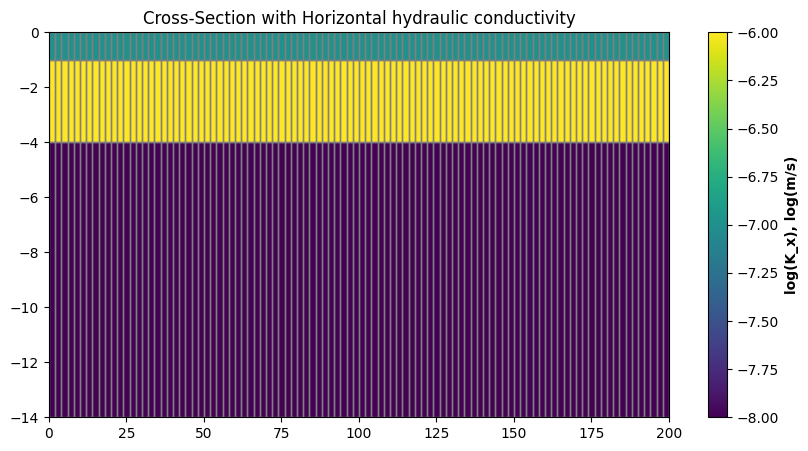

In [12]:
# plot the horizontal hydraulic conductivities
log_hk = np.log10(gwf.npf.k.array)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
cross_section_row = 5
xsect = flopy.plot.PlotCrossSection(model=gwf, line={"Row": cross_section_row})
csa = xsect.plot_array(log_hk)
linecollection = xsect.plot_grid()
t = ax.set_title(
    "Cross-Section with Horizontal hydraulic conductivity"
)
cb = plt.colorbar(csa)
cb.set_label(label="log(K_x), log(m/s)", weight="bold")

## Task 3: Prediction, Boundary condition

In [13]:
# Boundary condition
## Default is no flow boundary condition

## Constant head boundary conditions
## Add constant head boundaries for east and west sides.

###### Task 3: Prediction #######
###### Change the boundary condition below for the stream levels

west_head = 2 # West, 2m constant head
east_head = 1 # East, 1m constant head

chd_spd = [
    [0, i, 0, west_head] for i in range(sgrid.nrow)
] + [
    [0, i, sgrid.ncol-1, east_head] for i in range(sgrid.nrow)
]

chd = flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_spd)

## Task 3: Prediction, Recharge

In [14]:
###### Task 3: Prediction #######
###### Change the recharge value for the future prediction

# Recharge: you can estimate that by precipitation - ET
rch = flopy.mf6.ModflowGwfrcha(gwf, recharge=1e-9) #m/s

# Run and postprocessing visualization

## Run MODFLOW simulation

In [15]:
oc = flopy.mf6.ModflowGwfoc(gwf,
                            head_filerecord=f"{name}.hds",
                            budget_filerecord=f"{name}.cbc",
                            saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')]
)
gwf.name_file.save_flows = True

sim.write_simulation()
sim.run_simulation()


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model Lab4...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 100 based on size of stress_period_data
    writing package rcha_0...
    writing package oc...
FloPy is using the following executable to run the model: ../drive/MyDrive/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

        MODFLOW 6 compiled Nov 18 2025 19:10:59 with GCC version 11.4.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further an

(True, [])

## Compare Modeled groundwater table with observed groundwater table

In [16]:
hobj = gwf.output.head()
hds = hobj.get_data() # head as hds
gw_table =flopy.utils.postprocessing.get_water_table(hds).data

3.035194551624438
3.336866396047102
1.9033099839084262


(np.float64(-0.5), np.float64(99.5), np.float64(-0.5), np.float64(49.5))

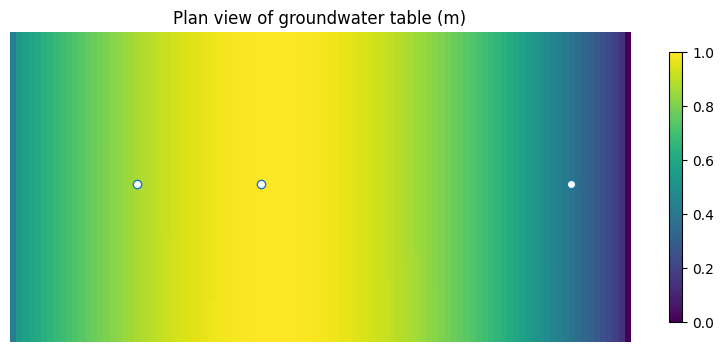

In [17]:
fig = plt.figure(figsize=(10, 5))
plt.imshow(gw_table, origin = 'lower')
for i,j in [[20,25],[40,25],[90,25]]:
  plt.scatter(i,j,edgecolor = 'C0',color = 'white')
  print(gw_table[j,i])
plt.colorbar(shrink = 0.7)
plt.title('Plan view of groundwater table (m)')
plt.axis('off')

Text(0.5, 1.0, 'Cross section of groundwater table (m)')

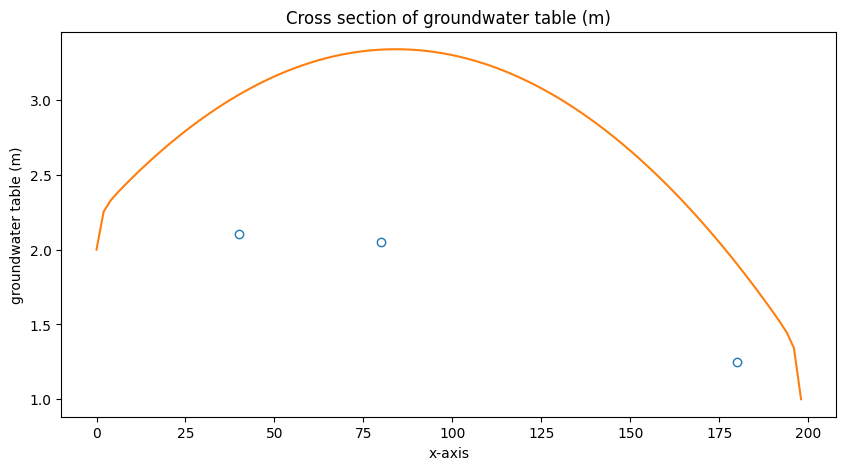

In [19]:
cross_section_row = 25
fig = plt.figure(figsize=(10, 5))
plt.scatter(np.array([20,40,90])*dx,observed_gw_tables,edgecolor = 'C0',color = 'white', label = 'Observed gw table')



plt.plot(np.arange(sgrid.ncol)*dx,gw_table[cross_section_row,:],color = 'C1', label = 'Modeled gw table')
plt.xlabel('x-axis')
plt.ylabel('groundwater table (m)')
plt.title('Cross section of groundwater table (m)')